# **Different integration schemes: Forward Euler, Backward Euler, Runge-Kutta method**
**Goal:**

In this lab, we are going to implement different types of integrators on a simple mechanical system.

1. We will analyze the differences between forward Euler, backward Euler and Runge-Kutta methods.
2. We will play with the value of dt, which defines the time step of integration, and through simulation we will see the effect of dt on the system behavior.


##**Simple Pendulum**
The dynamics of a simple pendulum (without friction) can be represented as follows:
\begin{equation}
\ddot{\theta} + \sin{\theta} = 0
\end{equation}

###**Linearization**



The linearization yelds the following:
\begin{equation}
\ddot \theta + \theta = 0
\end{equation}

With the state-space vector $\dot{\mathbf{x}}=[\theta, \dot{\theta}]^T$, we get:

\begin{equation}
\dot{\mathbf{x}} = \begin{bmatrix}
\, \dot{\theta} \\
-\theta \\
\end{bmatrix} =
\begin{bmatrix}
0 & 1 \\
-1 & 0 \\
\end{bmatrix}
\begin{bmatrix}
\theta \\
\dot{\theta}
\end{bmatrix} = \mathbf{A} \mathbf{x}
\end{equation}

---
\begin{equation}
\dot{x} = f(x)
\end{equation}




***Forward Euler:***
\begin{equation}
x_{k+1} = x_k + f(x_k) dt
\end{equation}

***Backward Euler:***
\begin{equation}
x_{k+1} = x_k + f(x_{k+1})dt
\end{equation}

To get the value $x_{k+1}$ one should solve the following equation:
\begin{equation}
x_{k+1} - x_k + f(x_{k+1})dt = 0
\end{equation}

***Runge-Kutta Method:***
\begin{equation}
x_{k+1} = x_k + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)dt
\end{equation}

where
\begin{equation}
\begin{matrix}
k_1 = f(x_k) \\
k_2 = f(x_k + dt \, \dfrac{k_1}{2}) \\
k_3 = f(x_k + dt \, \dfrac{k_2}{2}) \\
k_4 = f(x_k+dt\, k_3)
\end{matrix}
\end{equation}


In [48]:
import numpy as np
import time
from matplotlib.pyplot import *

In [62]:
dt = 0.001
t = 500 # amount of time to integrate
N = int(t / dt) # number of time points
t_span = np.linspace(0, t, N) # time span

# Initial condition
x0 = [2,0]

I = np.eye(2)
A = np.array([[0,1], [-1,0]])

In [63]:
xf = np.zeros((2,N))  # Forward euler trajectory
xf[:, 0] = x0         # update the array of states with initial condition

# Implement Forward euler
for k in range(N - 1):
    xf[:, k + 1] = xf[:, k] + dt * (A @ xf[:, k])

In [64]:
xb = np.zeros((2,N))  # Backward euler trajectory
xb[:, 0] = x0         # update the array of states with initial condition

# Implement Backward euler
inverse_matrix = np.linalg.inv(I - dt * A)

for i in range(N - 1):
    xb[:, i+1] = inverse_matrix @ xb[:, i]

In [65]:
xRK = np.zeros((2,N)) # Runge-Kutta trajectory
xRK[:, 0] = x0        # update the array of states with initial condition

for i in range(N - 1):
    x = xRK[:, i]
    
    k1 = A @ x
    k2 = A @ (x + dt/2 * k1)
    k3 = A @ (x + dt/2 * k2)
    k4 = A @ (x + dt * k3)
    
    xRK[:, i+1] = x + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

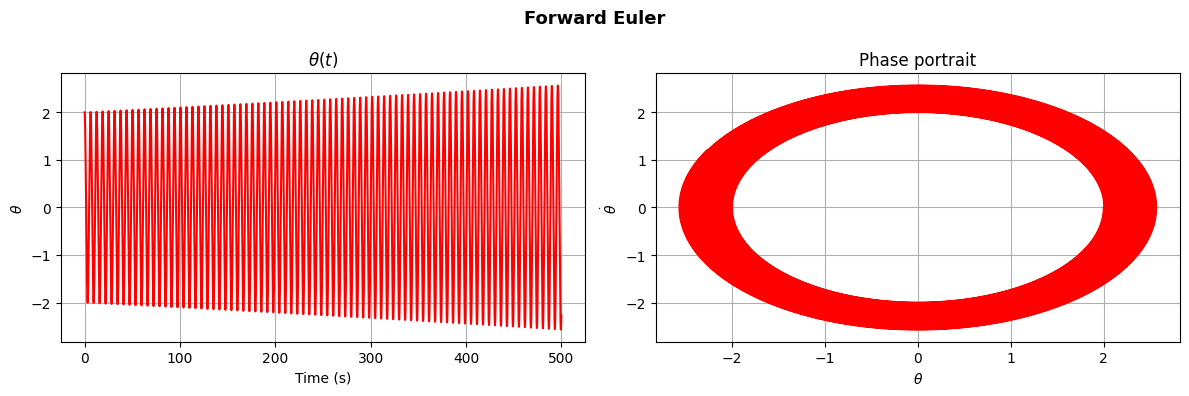

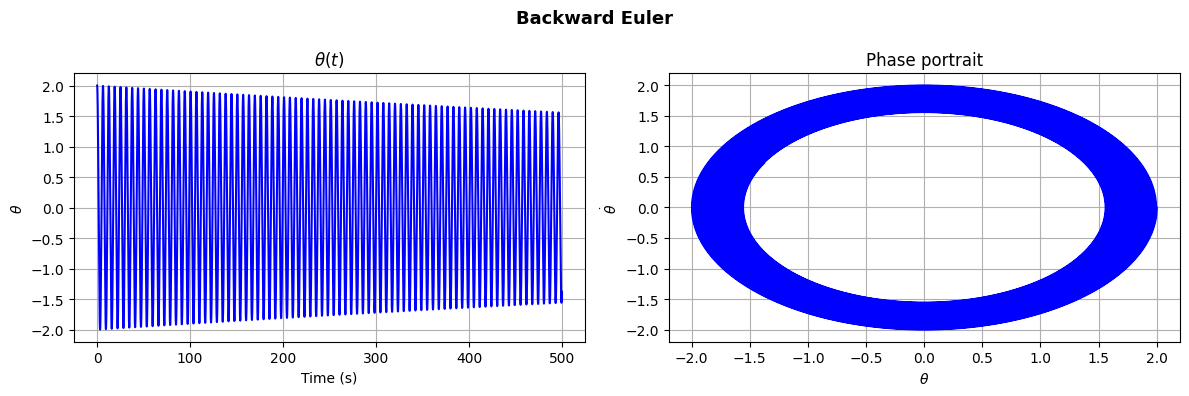

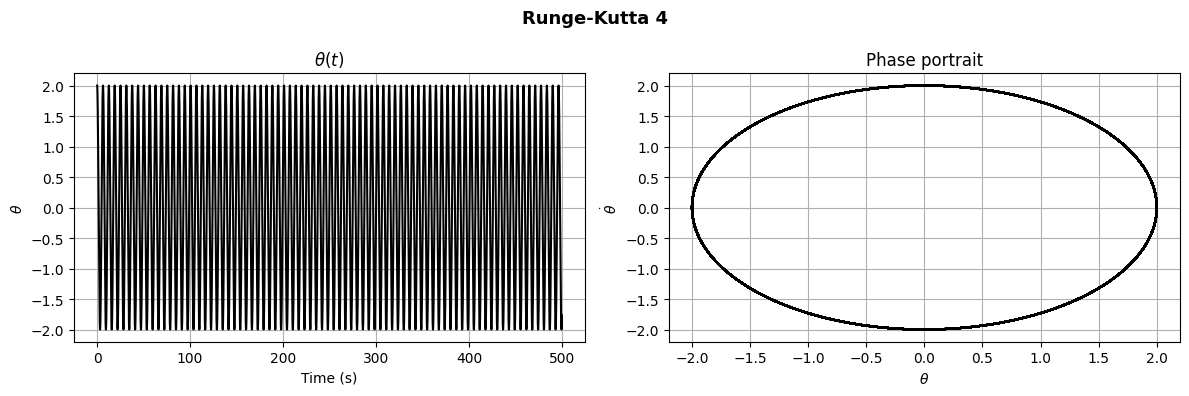

In [53]:
# --- Forward Euler ---
figure(figsize=(12, 4))
suptitle('Forward Euler', fontsize=13, fontweight='bold')
subplot(1, 2, 1)
plot(t_span, xf[0, :], color='r')
xlabel('Time (s)')
ylabel(r'$\theta$')
title(r'$\theta(t)$')
grid()
subplot(1, 2, 2)
plot(xf[0, :], xf[1, :], color='r')
xlabel(r'$\theta$')
ylabel(r'$\dot{\theta}$')
title('Phase portrait')
grid()
tight_layout()
show()

# --- Backward Euler ---
figure(figsize=(12, 4))
suptitle('Backward Euler', fontsize=13, fontweight='bold')
subplot(1, 2, 1)
plot(t_span, xb[0, :], color='b')
xlabel('Time (s)')
ylabel(r'$\theta$')
title(r'$\theta(t)$')
grid()
subplot(1, 2, 2)
plot(xb[0, :], xb[1, :], color='b')
xlabel(r'$\theta$')
ylabel(r'$\dot{\theta}$')
title('Phase portrait')
grid()
tight_layout()
show()

# --- Runge-Kutta 4 ---
figure(figsize=(12, 4))
suptitle('Runge-Kutta 4', fontsize=13, fontweight='bold')
subplot(1, 2, 1)
plot(t_span, xRK[0, :], color='k')
xlabel('Time (s)')
ylabel(r'$\theta$')
title(r'$\theta(t)$')
grid()
subplot(1, 2, 2)
plot(xRK[0, :], xRK[1, :], color='k')
xlabel(r'$\theta$')
ylabel(r'$\dot{\theta}$')
title('Phase portrait')
grid()
tight_layout()
show()

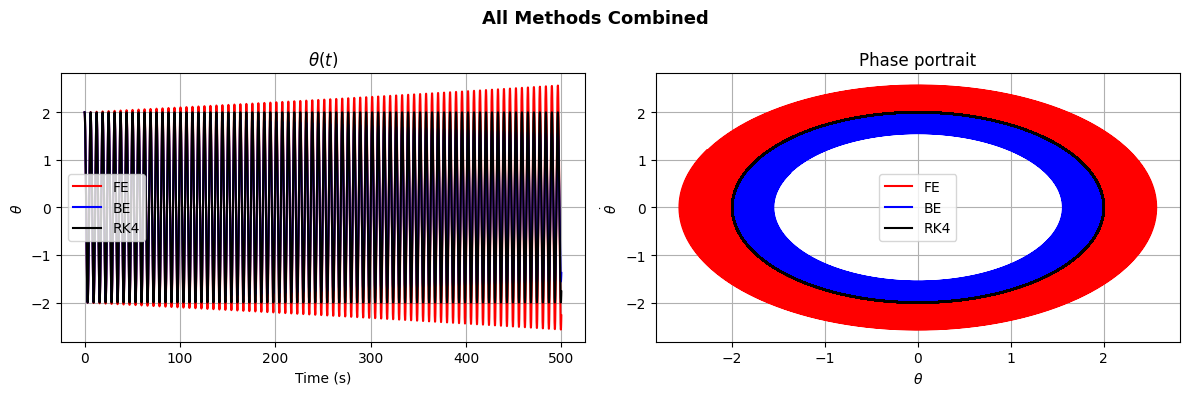

In [54]:
# --- All methods combined ---
figure(figsize=(12, 4))
suptitle('All Methods Combined', fontsize=13, fontweight='bold')

subplot(1, 2, 1)
plot(t_span, xf[0, :], color='r', label='FE')
plot(t_span, xb[0, :], color='b', label='BE')
plot(t_span, xRK[0, :], color='k', label='RK4')
xlabel('Time (s)')
ylabel(r'$\theta$')
title(r'$\theta(t)$')
grid()
legend()

subplot(1, 2, 2)
plot(xf[0, :], xf[1, :], color='r', label='FE')
plot(xb[0, :], xb[1, :], color='b', label='BE')
plot(xRK[0, :], xRK[1, :], color='k', label='RK4')
xlabel(r'$\theta$')
ylabel(r'$\dot{\theta}$')
title('Phase portrait')
grid()
legend()

tight_layout()
show()

Now you may play with dt a bit to see how the behavior of each integrator changes (you may apply the following values dt=0.4, dt=0.04, dt=0.001).

The next step which may be useful is to analyze the energy of the system. Total energy of the system is as folllows:
\begin{equation}
E_{total} = \frac{1}{2}(\theta^2 + \dot{\theta}^2)
\end{equation}

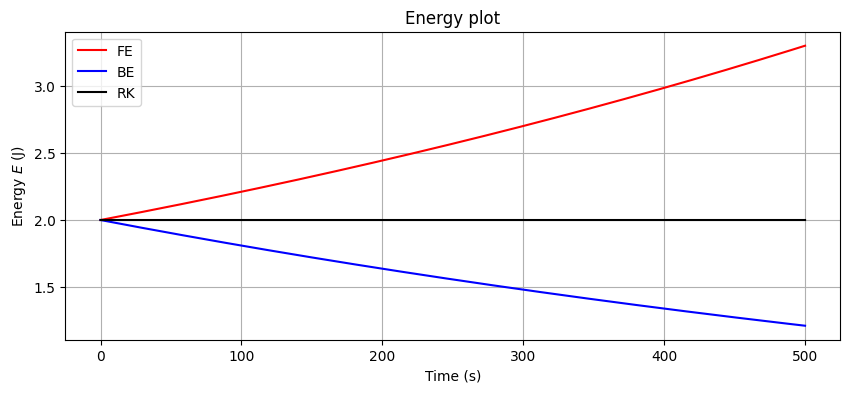

In [30]:
Ef_array = []   # array of energy values for Forward Euler
Eb_array = []   # array of energy values for Backward Euler
ERK_array = []  # array of energy values for Runge-Kutta method

# Implementation
Ef_array = 0.5 * (xf[0, :]**2 + xf[1, :]**2)
Eb_array = 0.5 * (xb[0, :]**2 + xb[1, :]**2)
ERK_array = 0.5 * (xRK[0, :]**2 + xRK[1, :]**2)

# Plot the energy
figure(figsize=(10, 4))
plot(t_span, Ef_array, color='r', label='FE')
plot(t_span, Eb_array, color='b', label='BE')
plot(t_span, ERK_array, color='k', label='RK')
title('Energy plot')
xlabel('Time (s)')
ylabel(r'Energy $E$ (J)')
grid()
legend()
show()

Compare the Runge-Kutta method implemented by you and Runge-Kutta method using `solve_ivp`

In [61]:
from scipy.integrate import solve_ivp

def f_linear(t, x):
    return A @ x

ivp_sol = solve_ivp(
    f_linear,
    (t_span[0], t_span[-1]),
    x0,
    t_eval=t_span,
    method='RK45'
)
xRK_ivp = ivp_sol.y

# --- Trajectory comparison ---
figure(figsize=(12, 4))
suptitle('RK4 (manual) vs RK45 (solve_ivp)', fontsize=13, fontweight='bold')
subplot(1, 2, 1)
plot(t_span, xRK[0, :], color='k', label='RK4 (manual)')
plot(t_span, xRK_ivp[0, :], color='g', linestyle='--', label='RK45 (solve_ivp)')
xlabel('Time (s)')
ylabel(r'$\theta$')
title('Angle trajectory')
grid()
legend()
subplot(1, 2, 2)
rk_error = np.linalg.norm(xRK - xRK_ivp, axis=0)
plot(t_span, rk_error, color='m')
xlabel('Time (s)')
ylabel(r'$\|x_{RK4} - x_{RK45}\|_2$')
title('State error over time')
grid()
tight_layout()
show()

# --- Energy comparison ---
E_RK4 = 0.5 * (xRK[0, :]**2 + xRK[1, :]**2)
E_RK45 = 0.5 * (xRK_ivp[0, :]**2 + xRK_ivp[1, :]**2)

figure(figsize=(12, 4))
suptitle('Energy: RK4 (manual) vs RK45 (solve_ivp)', fontsize=13, fontweight='bold')
subplot(1, 2, 1)
plot(t_span, E_RK4, color='k', label='RK4 (manual)')
plot(t_span, E_RK45, color='g', linestyle='--', label='RK45 (solve_ivp)')
xlabel('Time (s)')
ylabel(r'Energy $E$ (J)')
title('Energy over time')
grid()
legend()
subplot(1, 2, 2)
plot(t_span, np.abs(E_RK4 - E_RK45), color='m')
xlabel('Time (s)')
ylabel(r'$|E_{RK4} - E_{RK45}|$')
title('Energy difference')
grid()
tight_layout()
show()

print(f'Max state error : {rk_error.max():.6f}')
print(f'Max energy error: {np.abs(E_RK4 - E_RK45).max():.6f}')

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 2)

Method                   Avg time (s)
--------------------------------------
Forward Euler                  0.6367
Backward Euler                 0.2892
RK4 (manual)                   2.8233
RK45 (solve_ivp)               0.0220

Fastest: RK45 (solve_ivp)
Slowest: RK4 (manual)


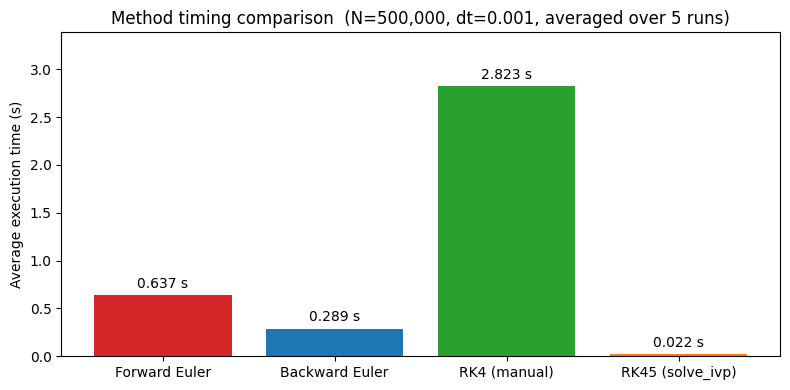

In [47]:
import time

RUNS = 5  # average over multiple runs for stable timing

def time_method(fn, runs=RUNS):
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return sum(times) / runs

# ── Forward Euler ─────────────────────────────────────────────
def run_fe():
    x = np.zeros((2, N)); x[:, 0] = x0
    for k in range(N - 1):
        x[:, k + 1] = x[:, k] + dt * (A @ x[:, k])

# ── Backward Euler ────────────────────────────────────────────
def run_be():
    x = np.zeros((2, N)); x[:, 0] = x0
    inv = np.linalg.inv(I - dt * A)
    for i in range(N - 1):
        x[:, i + 1] = inv @ x[:, i]

# ── RK4 (manual) ──────────────────────────────────────────────
def run_rk4():
    x = np.zeros((2, N)); x[:, 0] = x0
    for i in range(N - 1):
        xi = x[:, i]
        k1 = A @ xi;           k2 = A @ (xi + dt/2*k1)
        k3 = A @ (xi + dt/2*k2); k4 = A @ (xi + dt*k3)
        x[:, i + 1] = xi + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

# ── solve_ivp (RK45 adaptive) ─────────────────────────────────
from scipy.integrate import solve_ivp
def run_ivp():
    solve_ivp(lambda t, x: A @ x, (t_span[0], t_span[-1]), x0,
              t_eval=t_span, method='RK45')

t_fe  = time_method(run_fe)
t_be  = time_method(run_be)
t_rk4 = time_method(run_rk4)
t_ivp = time_method(run_ivp)

methods = ['Forward Euler', 'Backward Euler', 'RK4 (manual)', 'RK45 (solve_ivp)']
times   = [t_fe, t_be, t_rk4, t_ivp]

print(f"{'Method':<22} {'Avg time (s)':>14}")
print("-" * 38)
for m, t in zip(methods, times):
    print(f"{m:<22} {t:>14.4f}")
print(f"\nFastest: {methods[times.index(min(times))]}")
print(f"Slowest: {methods[times.index(max(times))]}")

# bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(methods, times, color=['#d62728','#1f77b4','#2ca02c','#ff7f0e'])
ax.bar_label(bars, fmt='%.3f s', padding=3)
ax.set_ylabel('Average execution time (s)')
ax.set_title(f'Method timing comparison  (N={N:,}, dt={dt}, averaged over {RUNS} runs)')
ax.set_ylim(0, max(times) * 1.2)
plt.tight_layout()
plt.show()


###**Nonlinear Case**
Now your task is to implement Forward/Backward Euler and Runge-Kutta method for a nonlinear system:
\begin{equation}
\ddot{\theta} + \sin{\theta} = 0
\end{equation}


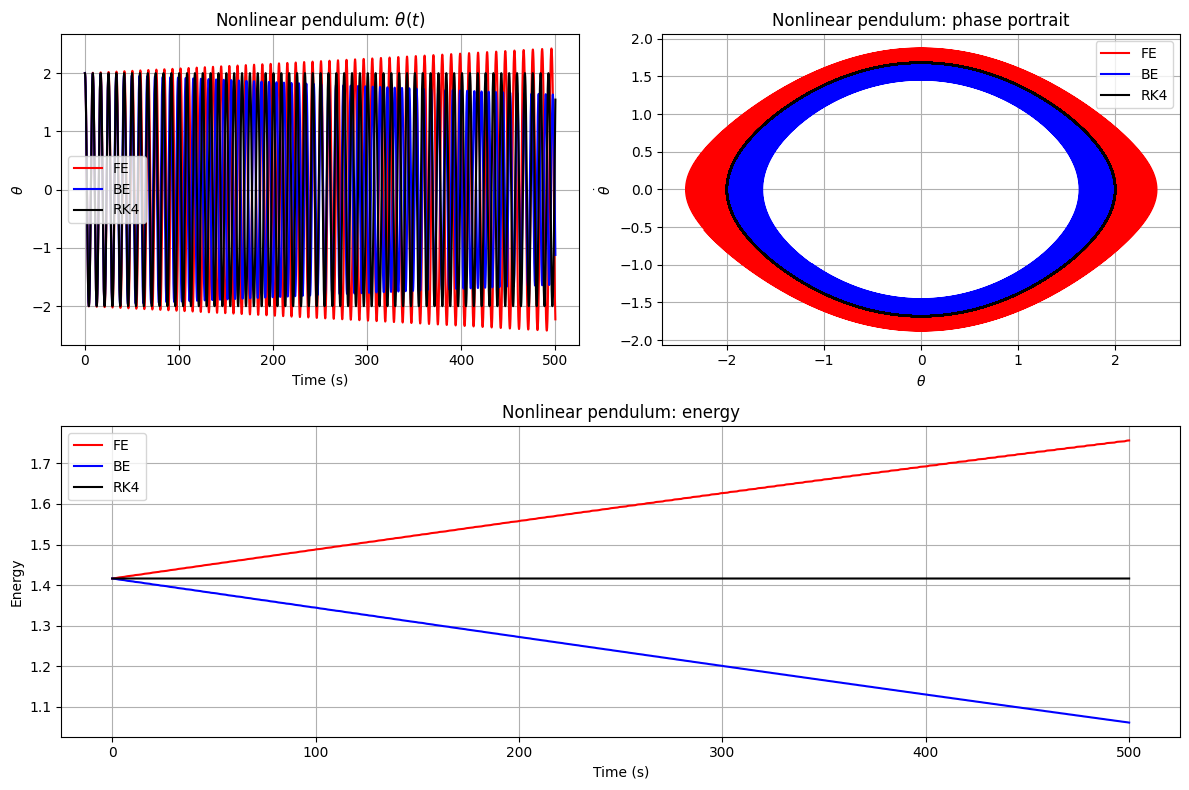

In [32]:
# Nonlinear pendulum: x = [theta, theta_dot]
def f_nl(x):
    theta, theta_dot = x
    return np.array([theta_dot, -np.sin(theta)])

xf_nl = np.zeros((2, N))
xb_nl = np.zeros((2, N))
xRK_nl = np.zeros((2, N))

xf_nl[:, 0] = x0
xb_nl[:, 0] = x0
xRK_nl[:, 0] = x0

# Forward Euler
for i in range(N - 1):
    xf_nl[:, i + 1] = xf_nl[:, i] + dt * f_nl(xf_nl[:, i])

# Backward Euler via fixed-point iteration
for i in range(N - 1):
    x_next = xb_nl[:, i].copy()
    for _ in range(8):
        x_next = xb_nl[:, i] + dt * f_nl(x_next)
    xb_nl[:, i + 1] = x_next

# RK4
for i in range(N - 1):
    x = xRK_nl[:, i]
    k1 = f_nl(x)
    k2 = f_nl(x + dt / 2 * k1)
    k3 = f_nl(x + dt / 2 * k2)
    k4 = f_nl(x + dt * k3)
    xRK_nl[:, i + 1] = x + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

# Nonlinear energy: E = 1/2 * theta_dot^2 + (1 - cos(theta))
Ef_nl = 0.5 * xf_nl[1, :]**2 + (1 - np.cos(xf_nl[0, :]))
Eb_nl = 0.5 * xb_nl[1, :]**2 + (1 - np.cos(xb_nl[0, :]))
ERK_nl = 0.5 * xRK_nl[1, :]**2 + (1 - np.cos(xRK_nl[0, :]))

figure(figsize=(12, 8))
subplot(2, 2, 1)
plot(t_span, xf_nl[0, :], 'r', label='FE')
plot(t_span, xb_nl[0, :], 'b', label='BE')
plot(t_span, xRK_nl[0, :], 'k', label='RK4')
title(r'Nonlinear pendulum: $\theta(t)$')
xlabel('Time (s)')
ylabel(r'$\theta$')
grid()
legend()

subplot(2, 2, 2)
plot(xf_nl[0, :], xf_nl[1, :], 'r', label='FE')
plot(xb_nl[0, :], xb_nl[1, :], 'b', label='BE')
plot(xRK_nl[0, :], xRK_nl[1, :], 'k', label='RK4')
title('Nonlinear pendulum: phase portrait')
xlabel(r'$\theta$')
ylabel(r'$\dot{\theta}$')
grid()
legend()

subplot(2, 1, 2)
plot(t_span, Ef_nl, 'r', label='FE')
plot(t_span, Eb_nl, 'b', label='BE')
plot(t_span, ERK_nl, 'k', label='RK4')
title('Nonlinear pendulum: energy')
xlabel('Time (s)')
ylabel('Energy')
grid()
legend()

tight_layout()
show()

## **Cart Pole Dynamics**

Recall the dynamics of cart-pole system:
\begin{equation}
\begin{cases}
\left(M+m\right){\ddot {p}}-m L \ddot{\theta} \cos \theta +m L \dot{\theta }^{2}\sin \theta = u \\
L \ddot{\theta}- g\sin \theta =\ddot{p} \cos \theta  \\
\end{cases}
\end{equation}

where $\theta$ is angle of the pendulum measured from the upper equilibrium and $p$ is position of cart


Choosing the state to be $\mathbf{x} = [\theta, \dot{\theta}, p, \dot{p}]^T$One may rewrite this dynamics in the state-space form as:
\begin{equation}
\mathbf{\dot{x}} =
\begin{bmatrix}
\dot{\theta} \\
\ddot{\theta} \\
\dot{p} \\
\ddot{p}
\end{bmatrix}
=
\begin{bmatrix}
\dot{\theta} \\
\frac{(M+m)g \sin \theta - mL \dot{\theta}^2 \sin\theta \cos\theta}{(M + m\sin^2 \theta)L} \\
\dot{p} \\
\frac{mg\sin\theta \cos\theta - mL\dot{\theta}^2 \sin \theta}{M + m\sin^2 \theta} \\
\end{bmatrix}
+
\begin{bmatrix}
0 \\
\frac{\cos\theta}{(M + m\sin^2 \theta)L} \\
0 \\
\frac{1}{M + m\sin^2 \theta} \\
\end{bmatrix} u
\end{equation}


###**System parameters**
Let us choose the following parameters:

In [35]:
import numpy as np
import time
from matplotlib.pyplot import *

In [57]:
m = 0.2 # mass of the pendulum
M = 0.5 # mass of the cart
L = 0.3 # length of the pendulum
g = 9.81

x0 = [0.2, 0, 0.1, 0]

dt = 0.4
t = 20 # amount of time to integrate
N = int(t / dt) # number of time points
t_span = np.linspace(0, t, N) # time span

Computation time (cart-pole simulation):
Forward Euler  : 0.4212 s
Backward Euler : 2.3566 s
RK4            : 1.7965 s
Fastest method: Forward Euler

Energy change over simulation (E_final - E_initial):
FE : 0.069652 J
BE : 0.016091 J
RK4: 0.012940 J


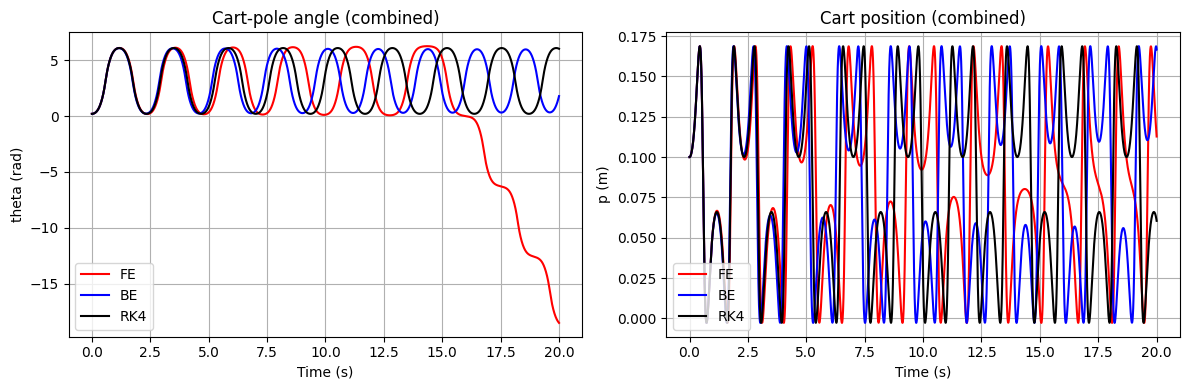

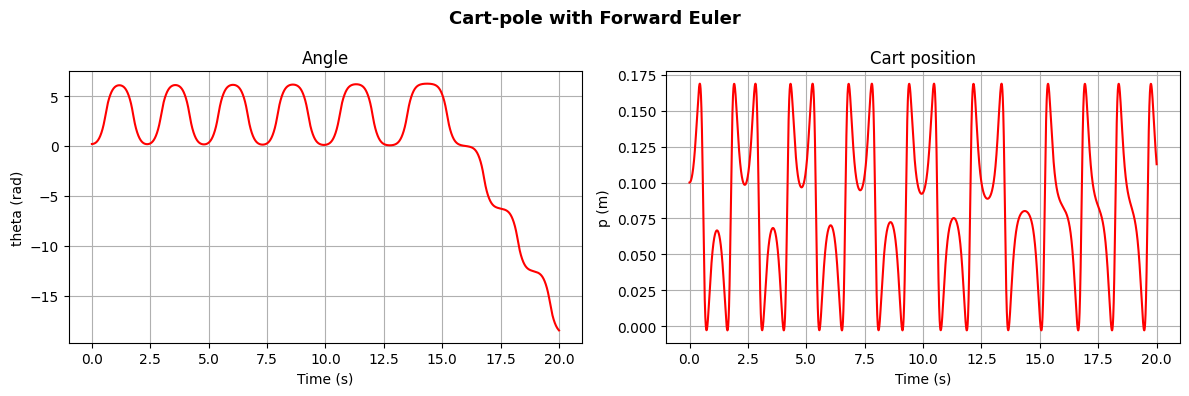

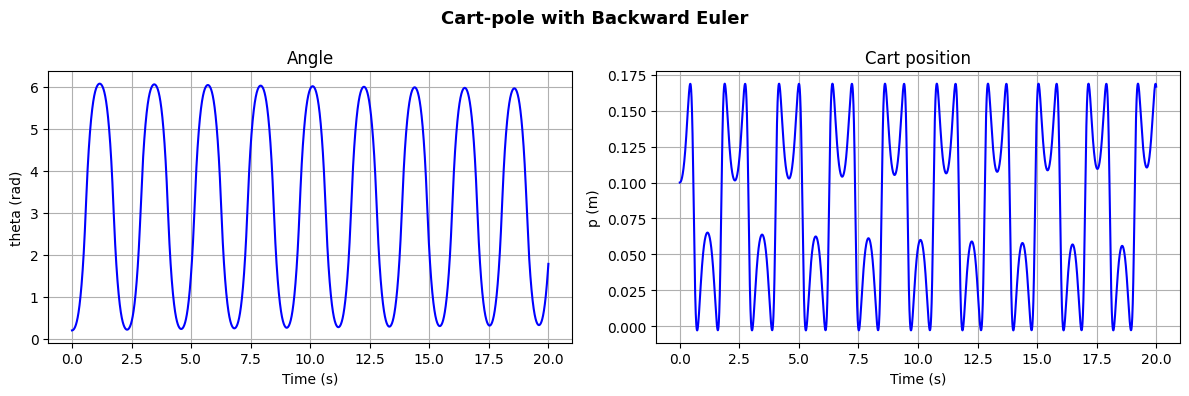

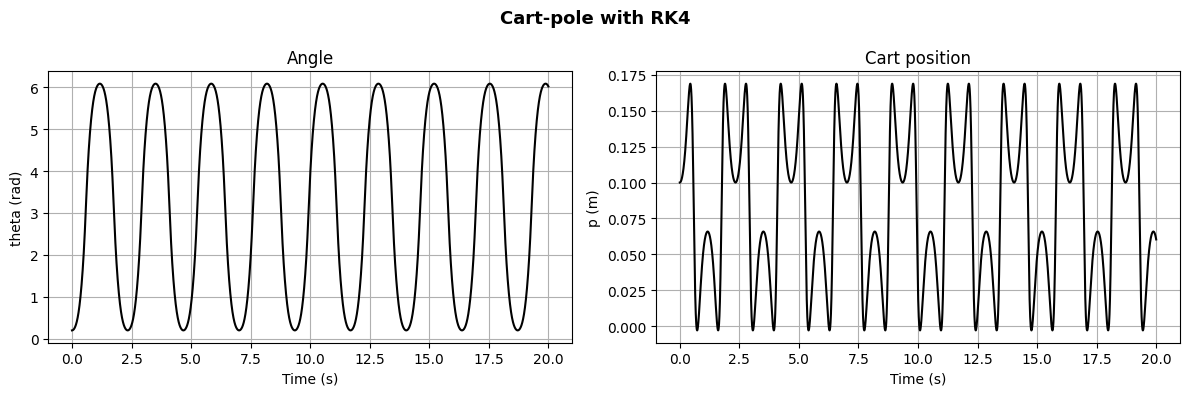

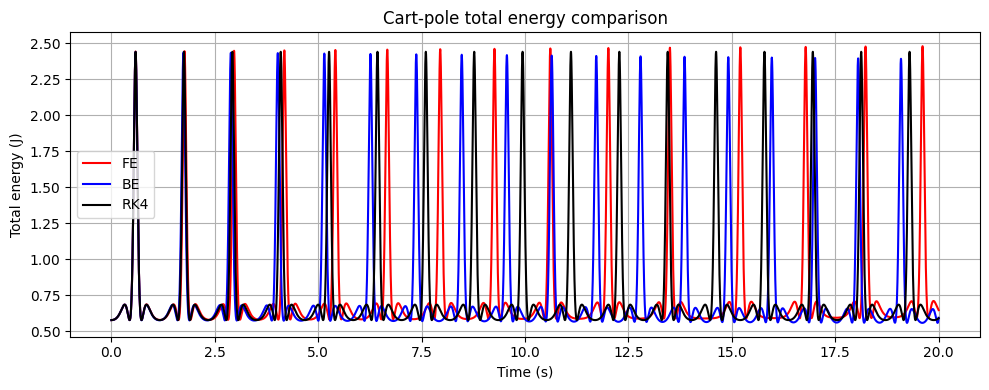

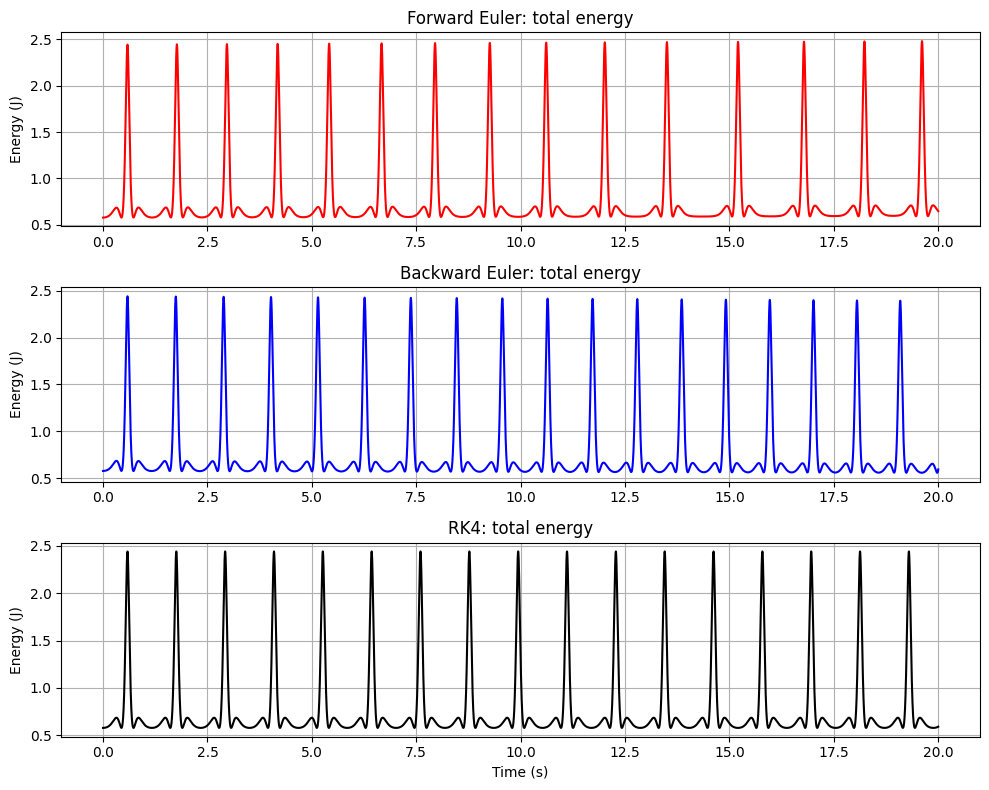

In [60]:
# Cart-pole simulation (u = 0) with FE, BE, and RK4
import time

m_cp = 0.2
M_cp = 0.5
L_cp = 0.3
g_cp = 9.81

x0_cp = np.array([0.2, 0.0, 0.1, 0.0])
dt_cp = 0.0001
t_cp = 20
N_cp = int(t_cp / dt_cp)
t_span_cp = np.linspace(0, t_cp, N_cp)

def cartpole_dynamics(x, u=0.0):
    theta, theta_dot, p, p_dot = x
    s = np.sin(theta)
    c = np.cos(theta)
    denom = M_cp + m_cp * s**2

    theta_ddot = ((M_cp + m_cp) * g_cp * s - m_cp * L_cp * theta_dot**2 * s * c + c * u) / (denom * L_cp)
    p_ddot = (m_cp * g_cp * s * c - m_cp * L_cp * theta_dot**2 * s + u) / denom

    return np.array([theta_dot, theta_ddot, p_dot, p_ddot])

# Forward Euler timing
t0 = time.perf_counter()
xcp_fe = np.zeros((4, N_cp))
xcp_fe[:, 0] = x0_cp
for i in range(N_cp - 1):
    xcp_fe[:, i + 1] = xcp_fe[:, i] + dt_cp * cartpole_dynamics(xcp_fe[:, i])
fe_time = time.perf_counter() - t0

# Backward Euler via fixed-point iteration on x_{k+1} = x_k + dt * f(x_{k+1})
t0 = time.perf_counter()
xcp_be = np.zeros((4, N_cp))
xcp_be[:, 0] = x0_cp
be_iters = 6
for i in range(N_cp - 1):
    x_next = xcp_be[:, i].copy()
    for _ in range(be_iters):
        x_next = xcp_be[:, i] + dt_cp * cartpole_dynamics(x_next)
    xcp_be[:, i + 1] = x_next
be_time = time.perf_counter() - t0

# RK4 timing
t0 = time.perf_counter()
xcp_rk4 = np.zeros((4, N_cp))
xcp_rk4[:, 0] = x0_cp
for i in range(N_cp - 1):
    x = xcp_rk4[:, i]
    k1 = cartpole_dynamics(x)
    k2 = cartpole_dynamics(x + dt_cp / 2 * k1)
    k3 = cartpole_dynamics(x + dt_cp / 2 * k2)
    k4 = cartpole_dynamics(x + dt_cp * k3)
    xcp_rk4[:, i + 1] = x + dt_cp / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
rk4_time = time.perf_counter() - t0

time_table = {
    'Forward Euler': fe_time,
    'Backward Euler': be_time,
    'RK4': rk4_time,
}
fastest = min(time_table, key=time_table.get)

print('Computation time (cart-pole simulation):')
for name, val in time_table.items():
    print(f'{name:<15}: {val:.4f} s')
print(f'Fastest method: {fastest}')

# Total energy of cart-pole (point-mass pendulum at length L)
def total_energy(xtraj):
    theta = xtraj[0, :]
    theta_dot = xtraj[1, :]
    p_dot = xtraj[3, :]

    kinetic = 0.5 * (M_cp + m_cp) * p_dot**2 + m_cp * L_cp * p_dot * theta_dot * np.cos(theta) + 0.5 * m_cp * (L_cp**2) * theta_dot**2
    potential = m_cp * g_cp * L_cp * np.cos(theta)
    return kinetic + potential

E_fe = total_energy(xcp_fe)
E_be = total_energy(xcp_be)
E_rk4 = total_energy(xcp_rk4)

print('\nEnergy change over simulation (E_final - E_initial):')
print(f"FE : {E_fe[-1] - E_fe[0]:.6f} J")
print(f"BE : {E_be[-1] - E_be[0]:.6f} J")
print(f"RK4: {E_rk4[-1] - E_rk4[0]:.6f} J")

# Combined plot: all three methods
figure(figsize=(12, 4))
subplot(1, 2, 1)
plot(t_span_cp, xcp_fe[0, :], 'r', label='FE')
plot(t_span_cp, xcp_be[0, :], 'b', label='BE')
plot(t_span_cp, xcp_rk4[0, :], 'k', label='RK4')
xlabel('Time (s)')
ylabel('theta (rad)')
title('Cart-pole angle (combined)')
grid()
legend()

subplot(1, 2, 2)
plot(t_span_cp, xcp_fe[2, :], 'r', label='FE')
plot(t_span_cp, xcp_be[2, :], 'b', label='BE')
plot(t_span_cp, xcp_rk4[2, :], 'k', label='RK4')
xlabel('Time (s)')
ylabel('p (m)')
title('Cart position (combined)')
grid()
legend()

tight_layout()
show()

# Separate plot: Forward Euler
figure(figsize=(12, 4))
suptitle('Cart-pole with Forward Euler', fontsize=13, fontweight='bold')
subplot(1, 2, 1)
plot(t_span_cp, xcp_fe[0, :], color='r')
xlabel('Time (s)')
ylabel('theta (rad)')
title('Angle')
grid()

subplot(1, 2, 2)
plot(t_span_cp, xcp_fe[2, :], color='r')
xlabel('Time (s)')
ylabel('p (m)')
title('Cart position')
grid()

tight_layout()
show()

# Separate plot: Backward Euler
figure(figsize=(12, 4))
suptitle('Cart-pole with Backward Euler', fontsize=13, fontweight='bold')
subplot(1, 2, 1)
plot(t_span_cp, xcp_be[0, :], color='b')
xlabel('Time (s)')
ylabel('theta (rad)')
title('Angle')
grid()

subplot(1, 2, 2)
plot(t_span_cp, xcp_be[2, :], color='b')
xlabel('Time (s)')
ylabel('p (m)')
title('Cart position')
grid()

tight_layout()
show()

# Separate plot: RK4
figure(figsize=(12, 4))
suptitle('Cart-pole with RK4', fontsize=13, fontweight='bold')
subplot(1, 2, 1)
plot(t_span_cp, xcp_rk4[0, :], color='k')
xlabel('Time (s)')
ylabel('theta (rad)')
title('Angle')
grid()

subplot(1, 2, 2)
plot(t_span_cp, xcp_rk4[2, :], color='k')
xlabel('Time (s)')
ylabel('p (m)')
title('Cart position')
grid()

tight_layout()
show()

# Energy comparison: all methods in one plot
figure(figsize=(10, 4))
plot(t_span_cp, E_fe, 'r', label='FE')
plot(t_span_cp, E_be, 'b', label='BE')
plot(t_span_cp, E_rk4, 'k', label='RK4')
xlabel('Time (s)')
ylabel('Total energy (J)')
title('Cart-pole total energy comparison')
grid()
legend()
tight_layout()
show()

# Energy behavior per method (separate subplots)
figure(figsize=(10, 8))
subplot(3, 1, 1)
plot(t_span_cp, E_fe, 'r')
title('Forward Euler: total energy')
ylabel('Energy (J)')
grid()

subplot(3, 1, 2)
plot(t_span_cp, E_be, 'b')
title('Backward Euler: total energy')
ylabel('Energy (J)')
grid()

subplot(3, 1, 3)
plot(t_span_cp, E_rk4, 'k')
title('RK4: total energy')
xlabel('Time (s)')
ylabel('Energy (J)')
grid()

tight_layout()
show()

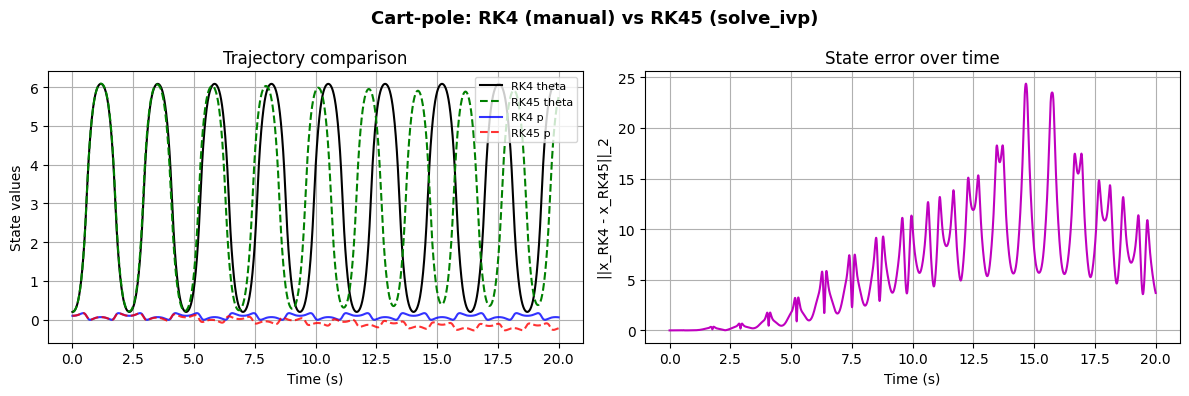

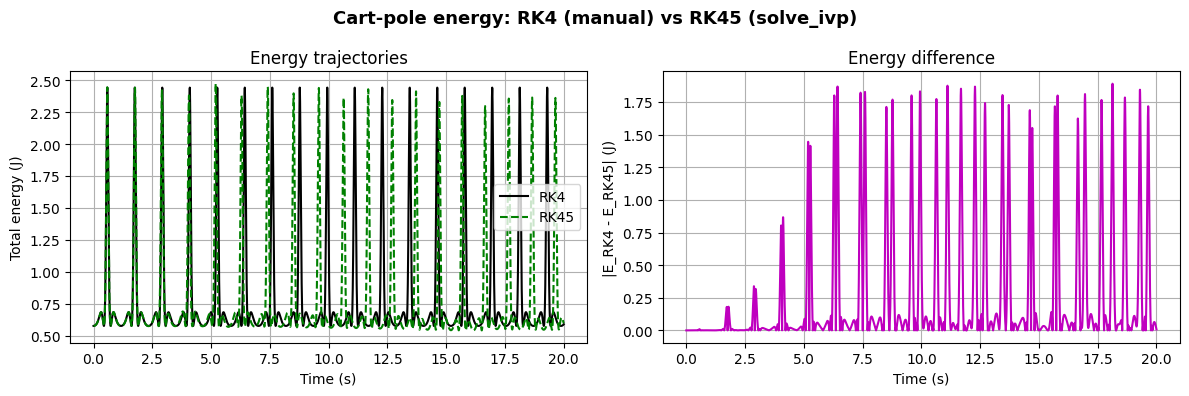

Max cart-pole state error  : 24.378859
Max cart-pole energy error : 1.890449 J
Energy drift RK4  (final-initial): 0.012940 J
Energy drift RK45 (final-initial): 0.020380 J


In [66]:
from scipy.integrate import solve_ivp

# Compare manual RK4 vs solve_ivp (RK45) for cart-pole
ivp_cp = solve_ivp(
    lambda t, x: cartpole_dynamics(x),
    (t_span_cp[0], t_span_cp[-1]),
    x0_cp,
    t_eval=t_span_cp,
    method='RK45'
)

xcp_ivp = ivp_cp.y

# State comparison
state_err_cp = np.linalg.norm(xcp_rk4 - xcp_ivp, axis=0)

figure(figsize=(12, 4))
suptitle('Cart-pole: RK4 (manual) vs RK45 (solve_ivp)', fontsize=13, fontweight='bold')
subplot(1, 2, 1)
plot(t_span_cp, xcp_rk4[0, :], 'k', label='RK4 theta')
plot(t_span_cp, xcp_ivp[0, :], 'g--', label='RK45 theta')
plot(t_span_cp, xcp_rk4[2, :], 'b', alpha=0.8, label='RK4 p')
plot(t_span_cp, xcp_ivp[2, :], 'r--', alpha=0.8, label='RK45 p')
xlabel('Time (s)')
ylabel('State values')
title('Trajectory comparison')
grid()
legend(loc='upper right', fontsize=8)

subplot(1, 2, 2)
plot(t_span_cp, state_err_cp, 'm')
xlabel('Time (s)')
ylabel('||x_RK4 - x_RK45||_2')
title('State error over time')
grid()

tight_layout()
show()

# Total energy function (same model used in cart-pole cell)
def total_energy_cp(xtraj):
    theta = xtraj[0, :]
    theta_dot = xtraj[1, :]
    p_dot = xtraj[3, :]

    kinetic = 0.5 * (M_cp + m_cp) * p_dot**2 + m_cp * L_cp * p_dot * theta_dot * np.cos(theta) + 0.5 * m_cp * (L_cp**2) * theta_dot**2
    potential = m_cp * g_cp * L_cp * np.cos(theta)
    return kinetic + potential

E_rk4_cp = total_energy_cp(xcp_rk4)
E_rk45_cp = total_energy_cp(xcp_ivp)
E_diff_cp = np.abs(E_rk4_cp - E_rk45_cp)

figure(figsize=(12, 4))
suptitle('Cart-pole energy: RK4 (manual) vs RK45 (solve_ivp)', fontsize=13, fontweight='bold')
subplot(1, 2, 1)
plot(t_span_cp, E_rk4_cp, 'k', label='RK4')
plot(t_span_cp, E_rk45_cp, 'g--', label='RK45')
xlabel('Time (s)')
ylabel('Total energy (J)')
title('Energy trajectories')
grid()
legend()

subplot(1, 2, 2)
plot(t_span_cp, E_diff_cp, 'm')
xlabel('Time (s)')
ylabel('|E_RK4 - E_RK45| (J)')
title('Energy difference')
grid()

tight_layout()
show()

print(f'Max cart-pole state error  : {state_err_cp.max():.6f}')
print(f'Max cart-pole energy error : {E_diff_cp.max():.6f} J')
print(f'Energy drift RK4  (final-initial): {E_rk4_cp[-1] - E_rk4_cp[0]:.6f} J')
print(f'Energy drift RK45 (final-initial): {E_rk45_cp[-1] - E_rk45_cp[0]:.6f} J')

### Newton's Method From Scratch (with quadratic example)

We implement Newton's method manually to solve a nonlinear equation:

\begin{equation}
f(x) = ax^2 + bx + c = 0
\end{equation}

Newton update rule:

\begin{equation}
x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}
\end{equation}

Then we compare the roots with `scipy.optimize.fsolve`.

Newton method results:
  start  4.00 -> root 3.000000000000 in 6 iterations
  start -2.00 -> root -0.500000000000 in 6 iterations

fsolve results:
  start  4.00 -> root 3.000000000000
  start -2.00 -> root -0.500000000000

Absolute differences (Newton vs fsolve):
  root from  4.00: 6.661e-14
  root from -2.00: 0.000e+00


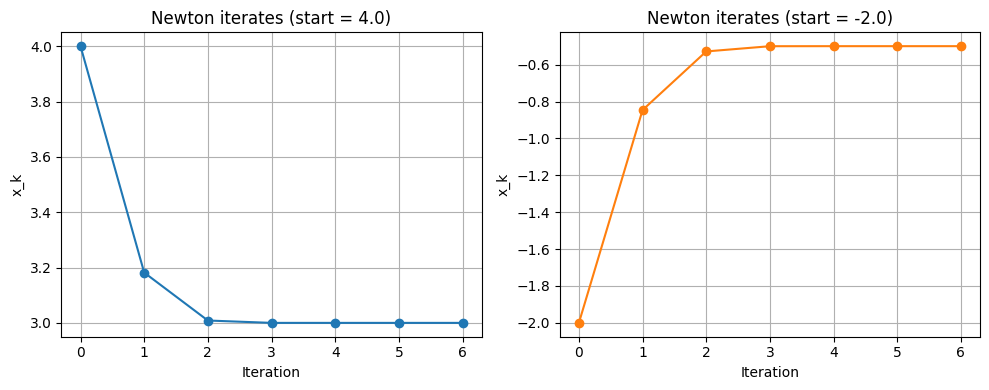

In [67]:
from scipy.optimize import fsolve

def newton_method(f, df, x0, tol=1e-10, max_iter=50):
    x = float(x0)
    history = [x]

    for k in range(max_iter):
        fx = f(x)
        dfx = df(x)

        if abs(dfx) < 1e-14:
            raise ZeroDivisionError(f"Derivative near zero at iter {k}, x={x}")

        x_new = x - fx / dfx
        history.append(x_new)

        if abs(x_new - x) < tol:
            return x_new, k + 1, history

        x = x_new

    return x, max_iter, history

# Example: 2x^2 - 5x - 3 = 0 -> roots should be 3 and -0.5
a, b, c = 2.0, -5.0, -3.0

f = lambda x: a * x**2 + b * x + c
df = lambda x: 2 * a * x + b

# Two initial guesses to converge to two different roots
x0_1 = 4.0
x0_2 = -2.0

root_n1, it1, hist1 = newton_method(f, df, x0_1)
root_n2, it2, hist2 = newton_method(f, df, x0_2)

# fsolve with same initial guesses
root_f1 = fsolve(f, x0_1)[0]
root_f2 = fsolve(f, x0_2)[0]

print('Newton method results:')
print(f'  start {x0_1:>5.2f} -> root {root_n1:.12f} in {it1} iterations')
print(f'  start {x0_2:>5.2f} -> root {root_n2:.12f} in {it2} iterations')

print('\nfsolve results:')
print(f'  start {x0_1:>5.2f} -> root {root_f1:.12f}')
print(f'  start {x0_2:>5.2f} -> root {root_f2:.12f}')

print('\nAbsolute differences (Newton vs fsolve):')
print(f'  root from {x0_1:>5.2f}: {abs(root_n1 - root_f1):.3e}')
print(f'  root from {x0_2:>5.2f}: {abs(root_n2 - root_f2):.3e}')

# Visualize convergence of iterates
figure(figsize=(10, 4))
subplot(1, 2, 1)
plot(hist1, marker='o')
title('Newton iterates (start = 4.0)')
xlabel('Iteration')
ylabel('x_k')
grid()

subplot(1, 2, 2)
plot(hist2, marker='o', color='tab:orange')
title('Newton iterates (start = -2.0)')
xlabel('Iteration')
ylabel('x_k')
grid()

tight_layout()
show()